# Pivot rules for partial Cholesky / Nyström

`rp_cholesky` builds a low-rank factor $F \in \mathbb{R}^{m\times r}$ with
$F F^\top \approx K$ by selecting $r$ pivot (landmark) columns and
Cholesky-completing against them. The pivot rows $F_S$ are exactly the Cholesky
factor of the landmark Gram $K_{SS}$, so $F F^\top$ is the **Nyström
approximation** for that landmark set — the only thing the `pivot` rule changes
is *which* landmarks get chosen:

- **`rp`** — randomly pivoted: sample the next pivot $s \propto$ residual
  diagonal (RPCholesky, Chen et al. 2023). Biased toward poorly-approximated
  points while staying random.
- **`greedy`** — classic pivoted Cholesky: always take the largest residual
  diagonal entry. Deterministic.
- **`uniform`** — uniform random pivots (classical Nyström). Ignores the
  residual entirely.

This notebook compares the trace-norm approximation error of the three rules as
a function of rank, first on a full-dimensional cloud and then on a
low-dimensional manifold.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from algs.kern_cd import rp_cholesky
from algs.kernels.rbf import RBF

rng = np.random.default_rng(0)
X = rng.random((1000, 2))

kernel = RBF(gamma="median").fit(X)
K = kernel(X)
print(f"K: {K.shape}, gamma={kernel.gamma:.3f}, trace={np.trace(K):.0f}")

K: (1000, 1000), gamma=1.881, trace=1000


## The kernel is effectively low rank

The RBF Gram matrix has a spectrum that decays several orders of magnitude
within the first ~50 eigenvalues, so a rank $r \ll m$ factorization can capture
almost all of it. That decay is exactly what the pivot rules are racing to
capture.

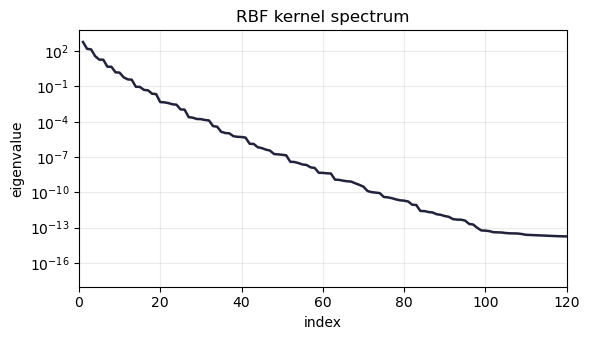

In [12]:
eigs = np.linalg.eigvalsh(K)[::-1]
eigs = eigs[eigs > 0]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(np.arange(1, len(eigs) + 1), eigs, lw=1.8, color="#22223b")
ax.set(xlabel="index", ylabel="eigenvalue", title="RBF kernel spectrum")
ax.set_xlim(0, 120)
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
plt.show()

## Error vs. rank for the three rules

We measure the **relative trace error**
$\;\operatorname{tr}(K - F F^\top) / \operatorname{tr}(K)\;$ — the natural error
norm for RPCholesky's guarantees, and equal to the leftover residual diagonal
mass. `rp` and `uniform` are randomized, so we average over 12 seeds and shade a
geometric $\pm1\sigma$ band (the error spans many decades, so an additive band
would dip below zero on the log axis). The helpers below are reused for the
manifold dataset later.

In [13]:
STYLE = {
    "rp":      dict(label="rp (RPCholesky)",    color="#e63946", marker="o"),
    "greedy":  dict(label="greedy",             color="#1d3557", marker="s"),
    "uniform": dict(label="uniform (Nyström)",  color="#7a8b99", marker="^"),
}

def rel_trace_error(F, K):
    "Relative trace-norm error tr(K - F F^T) / tr(K)."
    return (np.trace(K) - np.sum(F**2)) / np.trace(K)

def sweep(kernel, X, K, ranks, seeds=range(12)):
    "Relative trace error for every pivot rule x rank x seed."
    err = {r: np.empty((len(list(seeds)), len(ranks))) for r in STYLE}
    for rule in STYLE:
        for i, seed in enumerate(seeds):
            for j, r in enumerate(ranks):
                F, _ = rp_cholesky(kernel, X, rank=int(r), pivot=rule,
                                   rng=np.random.default_rng(seed))
                err[rule][i, j] = rel_trace_error(F, K)
    return err

def plot_curves(ax, ranks, err, title):
    "Error-vs-rank with a geometric +/-1 sigma band over seeds."
    for rule, s in STYLE.items():
        le = np.log(err[rule])
        m, sd = le.mean(0), le.std(0)
        ax.plot(ranks, np.exp(m), lw=2, ms=6, **s)
        ax.fill_between(ranks, np.exp(m - sd), np.exp(m + sd),
                        color=s["color"], alpha=0.18, lw=0)
    ax.set_yscale("log")
    ax.set_xlabel("rank $r$")
    ax.set_ylabel(r"relative trace error  $\mathrm{tr}(K - FF^\top)/\mathrm{tr}(K)$")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False)

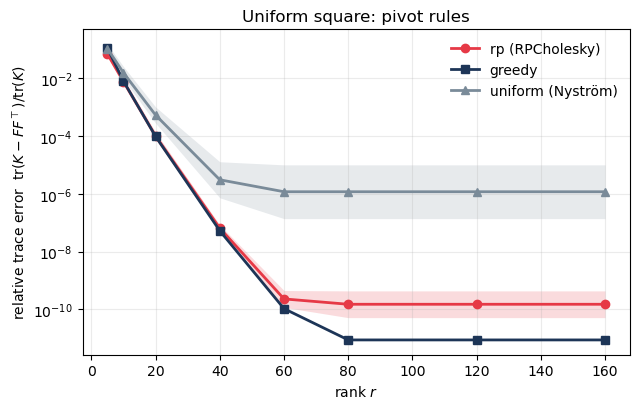

In [14]:
ranks = np.array([5, 10, 20, 40, 60, 80, 120, 160])

err = sweep(kernel, X, K, ranks)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_curves(ax, ranks, err, "Uniform square: pivot rules")
fig.tight_layout()
plt.show()

**Takeaway.** Residual-aware pivoting wins: `rp` and `greedy` drive the error
down far faster than `uniform`, which wastes landmarks on already-covered
regions. `greedy` is marginally ahead at equal rank but is deterministic and can
be fragile on adversarial spectra, whereas `rp` matches it on average while
retaining the randomization that underpins RPCholesky's trace-norm guarantees.

## A manifold-supported distribution: the Lissajous figure-eight

The uniform square is full-dimensional, so coverage is the only thing that
matters. Trajectory data instead concentrates near a low-dimensional manifold,
where the kernel is even more compressible and *where* a rule spends its
landmarks becomes visible. We sample a Lissajous figure-eight,
$\;x = \sin 2t,\; y = \sin t,\;$ a 1-D curve, with a little Gaussian thickness.

In [15]:
g = np.random.default_rng(1)
t = g.uniform(0, 2 * np.pi, 1000)
X8 = np.column_stack([np.sin(2 * t), np.sin(t)])
X8 += 0.02 * g.standard_normal(X8.shape)

kernel8 = RBF(gamma="median").fit(X8)
K8 = kernel8(X8)
print(f"K8: {K8.shape}, gamma={kernel8.gamma:.3f}")

K8: (1000, 1000), gamma=0.306


### Where each rule plants its landmarks

At a fixed rank the difference is geometric. `rp` and `greedy` spread landmarks
along the whole curve (each new pivot lands where the residual is largest, i.e.
where the curve is not yet covered), while `uniform` samples blindly — leaving
gaps on some arms and clumping on others.

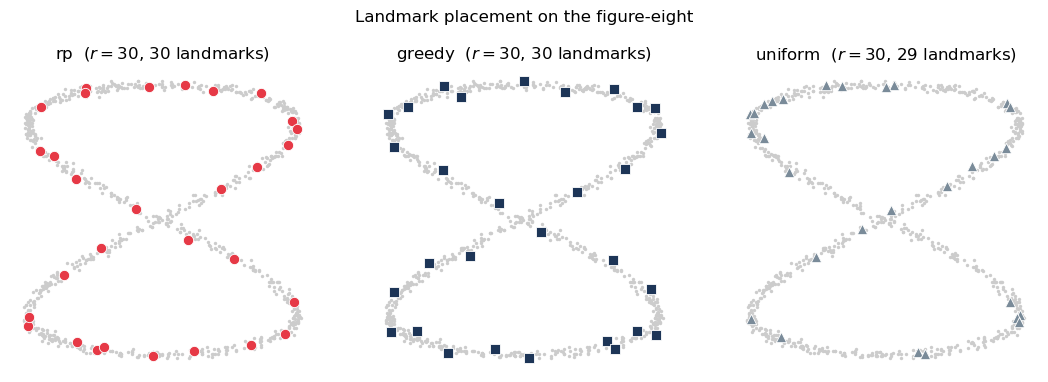

In [16]:
rank_show = 30
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharex=True, sharey=True)
for ax, (rule, s) in zip(axes, STYLE.items()):
    F, S = rp_cholesky(kernel8, X8, rank=rank_show, pivot=rule,
                       rng=np.random.default_rng(0))
    ax.scatter(*X8.T, s=6, color="0.8", lw=0)
    ax.scatter(*X8[S].T, s=55, color=s["color"], marker=s["marker"],
               edgecolor="white", lw=0.6, zorder=3)
    ax.set_title(f"{rule}  ($r={rank_show}$, {len(S)} landmarks)")
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle("Landmark placement on the figure-eight", y=1.02)
fig.tight_layout()
plt.show()

### Error vs. rank on the manifold

Same sweep as before. The intrinsic dimension is 1, so the spectrum collapses
even faster and a handful of well-placed landmarks suffice — widening the gap
between residual-aware pivoting and blind uniform sampling.

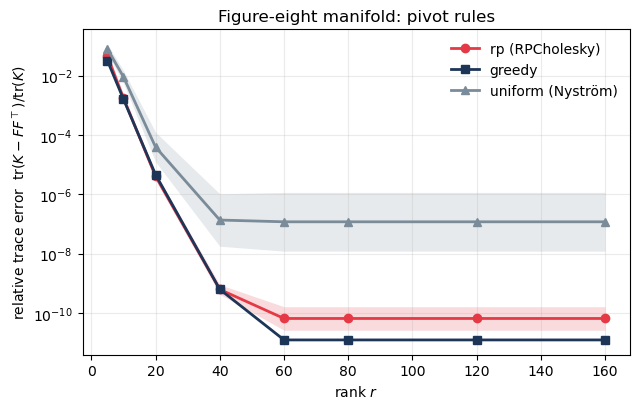

In [17]:
err8 = sweep(kernel8, X8, K8, ranks)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_curves(ax, ranks, err8, "Figure-eight manifold: pivot rules")
fig.tight_layout()
plt.show()

**Takeaway.** On the manifold the contrast sharpens: a few dozen residual-driven
landmarks already pin the curve to machine precision, while `uniform` plateaus
orders of magnitude higher and with much larger seed-to-seed variance — exactly
the regime (low intrinsic dimension, fast spectral decay) where RPCholesky is
designed to shine.